### Auto-Generated Code Cells

The following code cells contain code from external .py files that has been automatically added to remove these dependencies. This allows you to run this version of the SELENE notebook on Cloud platforms such as Google Colab. Run all following code cells before starting with the actual notebook content. 

Most Cloud platforms such as Google Colab have a wide range of Python packages preinstalled. However, if any import statements in the following code cells throws an error because of a missing package, you can create and run a new code cell to install the missing package using the `pip` command as shown here:
```
!pip install <package-name>
```

You can use the code cell below for convenience.

In [ ]:
#!pip install <package-name>

In [ ]:
# === Inline content for module src.utils.plotting.kmeans  ==

# === Inlined imports ===
from IPython.display import HTML
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle
import matplotlib.animation as animation
from matplotlib.ticker import MaxNLocator

# === Embedded configs ===


# === Inlined definitions ===
def plot_elbow(sse_data):
    plt.figure(figsize=(6, 5))
    plt.xlabel('K', fontsize=16)
    plt.ylabel('SSE', fontsize=18)
    plt.tick_params(axis='x', labelsize=12)
    plt.tick_params(axis='y', labelsize=12)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    if sse_data.ndim == 2:
        plt.errorbar([s[0] for s in sse_data], [s[1] for s in sse_data], [s[2] for s in sse_data], marker='o', capsize=3, lw=2, color='blue', alpha=0.6)
    else:
        plt.plot(sse_data, marker='o', lw=2, color='blue', alpha=0.6)
    plt.tight_layout()
    plt.show()

def update(frame, l, c, s):
    ax.clear()
    if frame == -1:
        labels = l
        centroids = c
        see = s
    else:
        labels = l[frame]
        centroids = c[frame]
        sse = s[frame]
    color_cycle = cycle(colors)
    if labels is not None:
        for cluster_id in np.unique(labels):
            cluster_sample_indices = np.where(labels == cluster_id)[0]
            X_cluster = X[cluster_sample_indices]
            if X_cluster.shape[0] > 0:
                ax.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), s=50, alpha=0.6)
                if centroids is not None and show_links is True:
                    for x in X_cluster:
                        ax.plot([x[0], centroids[cluster_id][0]], [x[1], centroids[cluster_id][1]], '--', linewidth=0.5, color='k'.format(cluster_id))
    else:
        plt.scatter(X[:, 0], X[:, 1], c='gray', s=50, alpha=0.6)
    color_cycle = cycle(colors)
    if centroids is not None:
        for centroid in centroids:
            ax.scatter(centroid[0], centroid[1], marker='+', color='black', s=250, lw=5)
    if frame >= 0:
        if frame % 2 == 0:
            ax.set_title(f'Assignment (SSE = {sse})')
        else:
            ax.set_title(f'Update (SSE = {sse})')
    elif s is not None:
        ax.set_title(f'SSE = {s}')

def plot_data(X, labels=None, centroids=None, sse=None, show_links=True, repeat=False):
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'teal', 'olive', 'maroon']
    color_cycle = cycle(colors)
    fig, ax = plt.subplots(figsize=(6, 5))
    plt.axis('equal')
    ax.set_xlabel('$x_1$', fontsize=18)
    ax.set_ylabel('$x_2$', fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    def update(frame, l, c, s):
        ax.clear()
        if frame == -1:
            labels = l
            centroids = c
            see = s
        else:
            labels = l[frame]
            centroids = c[frame]
            sse = s[frame]
        color_cycle = cycle(colors)
        if labels is not None:
            for cluster_id in np.unique(labels):
                cluster_sample_indices = np.where(labels == cluster_id)[0]
                X_cluster = X[cluster_sample_indices]
                if X_cluster.shape[0] > 0:
                    ax.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), s=50, alpha=0.6)
                    if centroids is not None and show_links is True:
                        for x in X_cluster:
                            ax.plot([x[0], centroids[cluster_id][0]], [x[1], centroids[cluster_id][1]], '--', linewidth=0.5, color='k'.format(cluster_id))
        else:
            plt.scatter(X[:, 0], X[:, 1], c='gray', s=50, alpha=0.6)
        color_cycle = cycle(colors)
        if centroids is not None:
            for centroid in centroids:
                ax.scatter(centroid[0], centroid[1], marker='+', color='black', s=250, lw=5)
        if frame >= 0:
            if frame % 2 == 0:
                ax.set_title(f'Assignment (SSE = {sse})')
            else:
                ax.set_title(f'Update (SSE = {sse})')
        elif s is not None:
            ax.set_title(f'SSE = {s}')
    if labels is not None and labels.ndim == 2:
        anim = animation.FuncAnimation(fig, update, frames=len(labels), fargs=(labels, centroids, sse), interval=1000, repeat=repeat)
        plt.close(fig)
        return HTML(anim.to_html5_video())
    else:
        update(-1, labels, centroids, sse)
        plt.tight_layout()
        plt.show()

def plot_sse_history(sse_values):
    plt.figure(figsize=(6, 5))
    x = np.arange(len(sse_values))
    x = x + 1
    x = x / 2
    x = x + 0.5
    plt.xlabel('Assignment/Update Step', fontsize=14)
    plt.ylabel('SSE', fontsize=18)
    plt.plot(x, sse_values, '-o', lw=3, color='blue', alpha=0.6)
    plt.tick_params(axis='x', labelsize=12)
    plt.tick_params(axis='y', labelsize=12)
    for idx, val in zip(x, sse_values):
        if idx == np.round(idx):
            plt.annotate('A', xy=(idx, val), fontsize=16)
        else:
            plt.annotate('U', xy=(idx, val), fontsize=16)
    plt.show()

In [ ]:
# === Inline content for module src.utils.data.files  ==

# === Inlined imports ===
import requests
import zipfile, tarfile
from tqdm import tqdm
import os, re, yaml
import bz2

# === Embedded configs ===
CONFIG = yaml.safe_load("""urls:
  downloads:
    notebooks: "https://github.com/chrisvdweth/selene/tree/master/notebooks"
    datasets: "https://chrisvdw.net/projects/selene/downloads/datasets/"
    models: "https://chrisvdw.net/projects/selene/downloads/models/"
    """)

# === Inlined definitions ===
def download_dataset(dataset_path, base_url=None, download_path=None, overwrite=False, ignore_html=True):
    if base_url is None:
        base_url = CONFIG['urls']['downloads']['datasets']
    if download_path is None:
        download_path = 'data/datasets/' + '/'.join(dataset_path.split('/')[0:-1]) + '/'
    url = base_url + dataset_path
    return download_file(url, download_path=download_path, overwrite=overwrite, ignore_html=ignore_html)

def download_file(url, download_path, overwrite=False, ignore_html=False):
    file_name = url.split('/')[-1]
    create_folder(download_path)
    file_path = download_path + file_name
    if os.path.isfile(file_path) == True and overwrite is not True:
        print(f"File '{file_path}' already exists (use 'overwrite=True' to overwrite it).")
        return (file_path, download_path)
    response = requests.get(url, stream=True)
    total_size_in_bytes = int(response.headers.get('content-length', 0))
    block_size = 1024
    progress_bar = tqdm(total=total_size_in_bytes, unit='iB', unit_scale=True)
    with open(file_path, 'wb') as file:
        for data in response.iter_content(block_size):
            if ignore_html is True and is_html_file(data) is True:
                print('Error downloading file (expected data file, got HTML file)')
                return (None, None)
            progress_bar.update(len(data))
            file.write(data)
    progress_bar.close()
    if total_size_in_bytes != 0 and progress_bar.n != total_size_in_bytes:
        print('Error downloading file (source does not exist)')
        return (None, None)
    return (file_path, download_path)

def is_html_file(content):
    content = content.decode('utf-8', 'ignore').strip().lower()
    if content.startswith('<!doctype html') is True:
        return True
    elif content.startswith('<html') is True:
        return True
    return False

def create_folder(folder_name, exist_ok=True):
    try:
        os.makedirs(folder_name, exist_ok=exist_ok)
        return folder_name
    except:
        return None

In [ ]:
# === Inline content for module src.utils.libimports.kmeans  ==

# === Inlined imports ===
from sklearn import datasets
import pandas as pd
from tqdm import tqdm
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import KMeans

# === Embedded configs ===


# === Inlined definitions ===


<img src="https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# K-Means

K-Means is one of the most widely used clustering algorithms in machine learning and data analysis. It is designed to find structure in unlabeled data by grouping similar data points together into clusters. Unlike supervised learning, where a model learns from labeled examples, clustering is an unsupervised learning technique: the goal is not to predict a known target, but to discover patterns that may not be immediately visible.

The basic idea behind K-Means is intuitive. Given a dataset and a chosen number of clusters, $K$, the algorithm assigns each data point to the nearest cluster center, called a centroid. It then updates each centroid based on the average position of the points assigned to it. By repeating these two steps, assignment and update, the algorithm gradually improves the cluster positions until they stabilize.

In this notebook, we will explore K-Means from both a conceptual and mathematical perspective. We will look at the objective function that K-Means tries to minimize, understand how distances are computed, and see why the algorithm converges through iterative refinement. To make the ideas more concrete, we will also implement K-Means from scratch, step by step, rather than relying only on existing machine learning libraries.

Learning K-Means is important because it provides a foundation for understanding many other clustering and optimization techniques. It is simple enough to implement and visualize, yet powerful enough to be used in real-world applications such as customer segmentation, image compression, document clustering, and exploratory data analysis. By studying K-Means carefully, you gain practical insight into how unsupervised learning algorithms discover structure in data.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
demo_data_triple, _     = download_dataset("tabular/clustering/clustering-data-triple-clusters.csv")
demo_data_densities1, _ = download_dataset("tabular/clustering/clustering-data-different-densities1.csv")
demo_data_densities2, _ = download_dataset("tabular/clustering/clustering-data-different-densities2.csv")
demo_data_moons, _      = download_dataset("tabular/clustering/clustering-data-moons.csv")
demo_data_circles, _    = download_dataset("tabular/clustering/clustering-data-circles.csv")
demo_data_random, _     = download_dataset("tabular/clustering/clustering-data-random.csv")
demo_data_outliers, _   = download_dataset("tabular/clustering/clustering-data-outliers.csv")

File 'data/datasets/tabular/clustering/clustering-data-triple-clusters.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-different-densities1.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-different-densities2.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-moons.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-circles.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-random.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-outliers.csv' already exists (use 'overwrite=True' to overwrite it).


---

## Overview

Unlike supervised learning, where the desired output is explicitly specified through labels, clustering lacks a universally accepted definition of what constitutes a "good" cluster. Concepts such as similarity, separation, density, connectivity, and shape can all play a role, and their relative importance depends heavily on the application and the data being analyzed. Because this notion is inherently subjective and context-dependent, no single clustering algorithm is suitable for all situations. Instead, a rich variety of clustering methods has been developed, each embodying different assumptions about the structure that should be considered a meaningful cluster. We therefore first need to discuss the fundamental ideas behind K-Means.

### Core Characteristics

Clustering algorithms can be categorized according to different characteristics. One of the most practical characteristics refers to the types of clusters and sets of clusters (i.e., clusterings) the algorithms are designed to discover. In more detail, K-Mean returns clustering with of the following types:

* **Partitional & exclusive:** K-Means splits all data points into non-overlapping subsets; a data point cannot belong to more than one cluster.
* **Complete:** All data points belong to one clusters; in contrast, in partial clusterings, a data point might not belong to any cluster.
* **Centroid-based:** K-Means does not directly consider the distance/similarity between pairs of data points, the distance between each point and the centroid of its assigned cluster. Two points may therefore be assigned to the same cluster even if they are relatively far apart from one another, provided they are both close to the cluster centroid. This centroid-based view of clustering distinguishes K-Means from methods that explicitly model pairwise relationships, such as hierarchical or graph-based clustering algorithms.

As we will discuss in a moment, K-Means relies on the Euclidean distance to compute the distance/similarity between data points and centroids. As such, K-Means assumes as input a dataset $D = \{\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_n \}$, with $\mathbf{x}_i \in \mathbb{R}^d$ &mdash; each data sample $\mathbf{x}_i$ is a point in the $d$-dimensional Euclidean space. This requires that categorical features need to be appropriately encoded as numerical features.

Lastly, apart from the dataset $D$, a distinguishing feature of K-Means is that the desired number of clusters, $K$, must be specified as input arguments before the algorithm is run. This requirement contrasts with many other clustering methods, such as DBSCAN or certain hierarchical clustering approaches, which can infer the number of clusters from the data itself based on density, connectivity, or other structural properties. Consequently, selecting an appropriate value of $K$ is an important practical consideration when applying K-Means. Again, we discuss the choice of $K$ later in the notebook.

### Optimization Objective

K-Means is best understood not as a specific step-by-step algorithm, but as an optimization problem. Its objective is to partition a dataset into $K$ clusters such that the **Sum of Squared Errors (SSE)**, also known as the within-cluster sum of squares, is minimized. Formally, K-Means seeks cluster assignments and cluster centroids that minimize the total squared Euclidean distance between each data point and the centroid of its assigned cluster. Mathematically, the SSE is defined as:

$$\large
\text{SSE} = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \lVert\mathbf{x}_i - \boldsymbol{\mu}_k\rVert^2
$$

where:

* $K$ = number of clusters
* $C_k$ = set of points assigned to cluster (k)
* $\mathbf{x}_i$ = the $i$-th data point
* $\boldsymbol{\mu}_k$ = centroid (mean) of the $k$-th cluster
* $\lVert\mathbf{x}_i - \boldsymbol{\mu}_k\rVert^2$ = squared Euclidean distance between the point $\mathbf{x}_i$ and its cluster centroid $\boldsymbol{\mu}_k$

As the expression above shows, the SSE objective encourages **compact clusters** by penalizing data points that lie far from their assigned centroid. Since the distances are squared, points that are far away contribute disproportionately to the objective, making such cluster assignments undesirable. As a result, minimizing SSE tends to produce clusters whose members are tightly grouped around a central location, leading to low within-cluster variability and high cluster compactness.

Because K-Means is defined through an optimization objective (i.e., minimizing the SSE) rather than a specific procedure, there are multiple algorithms that can be used to search for a good solution. These algorithms differ in how they update cluster assignments and centroids, as well as in their computational efficiency and convergence properties. By far the most widely used approach is **Lloyd's algorithm**, an iterative method that alternates between assigning each data point to its nearest centroid and recomputing the centroids based on the current assignments. Due to its simplicity and effectiveness, Lloyd's algorithm has become synonymous with K-Means in practice and will be the focus of this notebook.

**Important:** Although the K-Means objective is simple to state, finding the clustering that globally minimizes the SSE is computationally difficult. In fact, the K-Means optimization problem is NP-hard, meaning that no efficient algorithm is known for finding the global optimum in all cases. An algorithm that is guaranteed to find the optimal solution runs in $O(n^{dk+1})$.Consequently, practical algorithms do not attempt an exhaustive search over all possible cluster assignments. Instead, methods such as Lloyd's algorithm employ heuristics that iteratively improve the objective and typically produce high-quality solutions in practice. While these methods are guaranteed to converge to a locally optimal solution, the final clustering may depend on the initialization and is not guaranteed to achieve the globally minimal SSE. We will explore this challenge later in the notebook.

### What is a Centroid?

In the previous section, we already "gave away" that the centroid of a cluster is the mean of all data points within that cluster. Although the notion of a cluster centroid may seem obvious, it is actually tied closely to the optimization objective being used. In K-Means, the centroid is defined as the arithmetic mean of all points assigned to a cluster because the SSE objective is based on **squared Euclidean distances**. A fundamental result from optimization shows that the point minimizing the sum of squared Euclidean distances to a set of observations is precisely their mean. To actually show this mathematically, let's have another look at the definition of the SSE:

$$\large
\text{SSE} = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \lVert\mathbf{x}_i - \boldsymbol{\mu}_k\rVert^2
$$

In simple terms, the SSE is some function that returns some value for a current allocation of all data points to a cluster, i.e., a current clustering. We can therefore ask: *"For a current clustering, what values for $\boldsymbol{\mu}_k$ minimize the SSE?"* Using calculus, we can answer this questions by computing the derivative of the SSE with respect to $\boldsymbol{\mu}_k$, set the derivative to $0$, and lastly solve for $\boldsymbol{\mu}_k$. Let's start by computing the derivative. Since all clusters are equal, we can focus on a single cluster $k$; this simplifying the expression of SSE by ignoring the sum over all clusters:

$$
\begin{align}
\large \frac{\partial SSE_k}{\partial \boldsymbol{\mu}_k}\ &\large = \frac{\partial}{\partial \boldsymbol{\mu}_k} \sum_{\mathbf{x}_i \in C_k} \lVert\mathbf{x}_i - \boldsymbol{\mu}_k\rVert^2\\[0.75em]
&\large = \sum_{\mathbf{x}_i \in C_k} \frac{\partial}{\partial \boldsymbol{\mu}_k} \lVert\mathbf{x}_i - \boldsymbol{\mu}_k\rVert^2\\[0.75em]
&\large = \sum_{\mathbf{x}_i \in C_k} \frac{\partial}{\partial \boldsymbol{\mu}_k} (\mathbf{x}_i-\boldsymbol{\mu}_k)^T (\mathbf{x}_i-\boldsymbol{\mu}_k)\\[0.75em]
&\large = \sum_{\mathbf{x}_i \in C_k} \frac{\partial}{\partial \boldsymbol{\mu}_k} \left(\mathbf{x}_i^T\mathbf{x}_i-2\mathbf{x}_i^T\boldsymbol{\mu}_k + \boldsymbol{\mu}_k^T\boldsymbol{\mu}_k \right)\\[0.75em]
&\large = \sum_{\mathbf{x}_i \in C_k} \left(-2\mathbf{x}_i+2\boldsymbol{\mu}_k\right)\\[0.75em]
&\large = 2 \sum_{\mathbf{x}_i \in C_k} (\boldsymbol{\mu}_k - \mathbf{x}_i)
\end{align}
$$

When setting this derivative to $0$ and solve for $\boldsymbol{\mu}_k$, we can ignore the constant factor of $2$; The rest is simply basic algebraic transformation to yield and expression for $\boldsymbol{\mu}_k$:

$$
\begin{align}
\large \sum_{\mathbf{x}_i \in C_k} (\boldsymbol{\mu}_k - \mathbf{x}_i)\ &\large = 0\\[0.75em]
\large \sum_{\mathbf{x}_i \in C_k} \boldsymbol{\mu}_k - \sum_{\mathbf{x}_i \in C_k}\mathbf{x}_i\ &\large = 0\\[0.75em]
\large \sum_{\mathbf{x}_i \in C_k} \boldsymbol{\mu}_k \ &\large = \sum_{\mathbf{x}_i \in C_k}\mathbf{x}_i\\[0.75em]
\large |C_k|\boldsymbol{\mu}_k \ &\large = \sum_{\mathbf{x}_i \in C_k}\mathbf{x}_i\\[0.75em]
\large \boldsymbol{\mu}_k \ &\large = \frac{1}{|C_k|}\sum_{\mathbf{x}_i \in C_k}\mathbf{x}_i\\[0.75em]
\end{align}
$$

where $|C_k|$ is the size of the cluster $k$ in terms of the number of data points in that cluster. This expression now shows that the value of $\boldsymbol{\mu}_k$ that minimizes the SSE for a given clustering is indeed the mean of the cluster, and therefore the mean for each of the $K$ clusters.

**Important:** If a different distance measure were used, such as the Manhattan (L1) distance, the optimal cluster representative would no longer be the mean but the median. Thus, the definition of a centroid in K-Means is not arbitrary; it follows directly from the choice of distance metric and the corresponding optimization objective. The special role of the Euclidean distance extends beyond the definition of the centroid. Under the squared Euclidean distance, the cluster mean is the unique minimizer of the within-cluster objective, which allows Lloyd's algorithm to alternate between assignment and centroid-update steps while guaranteeing that the SSE never increases. 

Consequently, the algorithm is guaranteed to converge to a local optimum after a finite number of iterations. When alternative distance measures are used, however, the optimal cluster representative may no longer be the mean and may even lack a simple closed-form solution. More importantly, the centroid-update step may no longer guarantee a monotonic decrease of the objective function, making convergence properties substantially more complicated. As a result, extending K-Means beyond the squared Euclidean distance often requires specialized algorithms, and the convergence guarantees enjoyed by Lloyd's algorithm do not necessarily carry over.

---

## Lloyd's Algorithm

Although finding the globally optimal solution for K-Means is NP-hard in general the algorithm most commonly associated with K-Means &mdash; **Lloyd's algorithm** &mdash; is conceptually very simple. It alternates between assigning each data point to its nearest centroid (assignment step) and recomputing the centroids as the means of the resulting clusters (update step). Ignoring implementation details and optimizations required for efficiently handling large datasets, each iteration consists of these two intuitive steps and is straightforward to implement. Despite offering no guarantee of finding the global optimum, Lloyd's algorithm often produces useful clusterings in practice, making it one of the most widely used unsupervised learning algorithms.

Before introducing the two main steps of LLoyd's algorithm, we first define a simple dataset we use throughout the explanation for the algorithm. To this end, the code cell below uses the [`make_blobs()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) method of the [scikit-learn](https://scikit-learn.org/) library to generate a $2$-dimensional dataset with, by default, $5$ centers and a standard deviation chose such the data points are not too close to their centers. We also provide the auxiliary method `plot_data()` which we will be using the plot the data as well as the cluster results. Of course, right now, we only have the data.

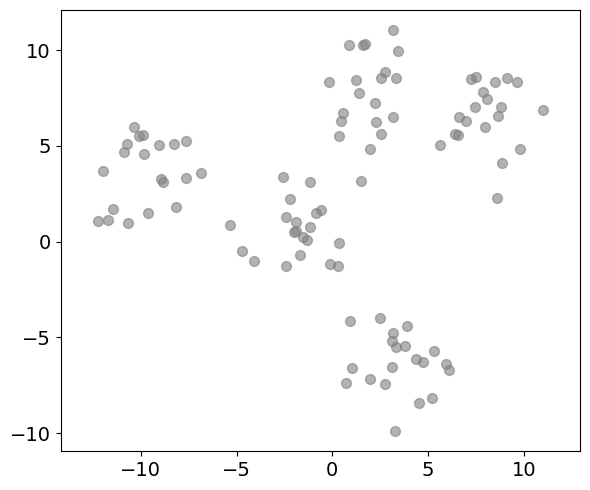

In [3]:
X, _ = datasets.make_blobs(n_samples=100, centers=5, n_features=2, cluster_std=1.5, random_state=20)

plot_data(X)

In the following, we are assuming the dataset generated by the given default parameters. However, you are welcome to change the arguments of the [`make_blobs()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) methods to generate differen datasets, e.g., using more or less centers or favoring more or less compact data distributions by changing the standard distributions. The only argument that cannot be changed is `n_features=2` since the plotting method assumes $2$-dimensional data.

### (Naive) Initialization

Before we can iteratively perform the assignment and update step, we first have to initialize the $K$ centroids &mdash; that is, we have to assign some initial values to each of $K$ centroids to start computing the distances between them and the data points. In principle, Lloyd’s algorithm does not change its procedure based on how the centroids are initialized. Regardless of the starting positions, it repeatedly performs the same two steps: assignment and update. This iterative process continues until convergence.

However, the initialization of the centroids can influence the final clustering result. Since Lloyd’s algorithm optimizes a non-convex objective and typically converges to a local optimum, different starting centroid locations may lead the algorithm to converge to different solutions, potentially with different cluster assignments and objective values. Thus, while the algorithm itself is independent of the initialization strategy, the quality and characteristics of the resulting clustering are often sensitive to the initial centroid placement.

Let's therefore start with a simple initialization, see which pathological case may happen, and then &mdash; once we covered LLoyd's algorithm &mdash; cover the most commonly used initialization: **K-Means++ initialization**. The initialization we first consider places the $K$ centroid at the location of $K$ randomly selected data points, without replacement to avoid duplicate centroids. Note that centroids do not have to be initialized at the exact location of centroids. However, it is an easy way to ensure the centroids are placed somewhere around the majority of data points. 

The method `init_centroids()` implements this idea using the [`choice()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) if NumPy to randomly select $K$ indices between $1$ and $n-1$, without duplicates. It then uses these indices to return that $K$ respective data points. Note that the implementation also accepts a prespecified list of centroids and simply returns those "as is". We only do this so we can later manually place centroids to use examples to see how sensitive K-Means to the initialization of centroids.

In [4]:
def init_centroids_basic(X, k=2, centroids=None):
    if centroids is not None:
        return np.asarray(centroids)
    else:
        indices = np.random.choice(X.shape[0], size=k, replace=False)
        return X[indices]

Let's run this method to get a list of centroids; by default, we set $K=5$. Again, while you can (and should) play with the value for $K$ as well as with the random seed, the following explanations and discussion assume these default values when running all examples. We therefore recommend first going through the notebook using those default values, and then come back and play with them.

In [5]:
np.random.seed(0)

centroids = init_centroids_basic(X, k=5)

When provided as an input argument, the auxiliary method `plot_data()` also shows the location of the centroids as bold plus signs. Just run the code cell below to plot all the $K$ centroids we get from the `init_centroids()` method.

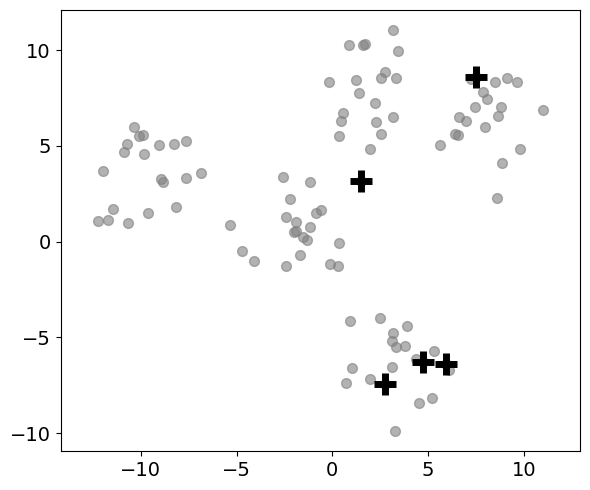

In [6]:
plot_data(X, centroids=centroids)

Just by eye-balling the plot, you wonder whether this a good initial choice for the centroids, particularly since three of them are rather bunched up together; recall that we only guarantee that we do not have duplicate centroids. And indeed, as we will later, some initialization may quickly lead to (very) suboptimal results. However, apart from really bad initial locations (examples shown later), it is generally not possible how good or well-behaved an initialization of centroids is.

In any case, this is our starting point. Having the centroids now allows us to compute the distance between the centroids and the data points required for both the assignment and update step.

### Assignment Step

In the assingment step, we assign each data point to its nearest centroid. In more detail, for each data point $\mathbf{x}_i$ we compute its distance to all $K$ centroids $\boldsymbol{\mu}_k$ and assign $\mathbf{x}_i$ to the cluster with the shortest distance. The method `assign_clusters()` implements the assignment step; note that we use the method [`euclidean_distances()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.euclidean_distances.html) of the [scikit-learn](https://scikit-learn.org/) library to compute the Euclidean distance between all pairs of data points and centroids. We represent the cluster assignment using the list `labels` where its $i$-th entry represent the label (i.e., cluster ID) of the cluster $\mathbf{x}_i$ is assignment to. The cluster IDs are of the range $0$ to $K-1$. This representation is in line with one for [`Kmeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) in the [scikit-learn](https://scikit-learn.org/) library.

In [7]:
def assign_clusters(X, centroids):

    # Compute the distances between all pairs of data points and centroids
    distances = euclidean_distances(X, centroids)

    # For all data points find the index of the centroids with the minimum distance
    # Use that index as the cluster label / cluster ID
    return np.argmin(distances, axis=1)

**Important:** In practice, implementations of clustering algorithms employ various optimization strategies to efficiently compute distances between centroids and data points. Since distance calculations are performed repeatedly during each iteration and often dominate the computational cost, techniques such as vectorized operations, efficient data structures, and pruning methods are used to reduce the number of calculations and improve scalability on large datasets. However, our focus is on illustrating the fundamental steps of LLoyd's algorithm.

We can now execute the method `assign_clusters()` for our dataset and our current (i.e., initial) choice of centroids to perform the first assignment step.

In [8]:
labels = assign_clusters(X, centroids)

print(labels)

[3 1 2 1 1 3 1 0 1 1 3 1 3 2 1 1 2 0 2 1 1 4 1 2 3 1 0 1 4 1 4 3 1 1 3 1 3
 1 3 3 3 2 1 1 1 3 3 1 2 1 3 1 3 1 1 3 1 3 3 1 1 2 1 1 3 4 1 3 2 3 1 1 1 3
 1 4 1 3 3 1 3 1 1 1 4 1 1 1 4 3 1 3 1 1 1 3 1 1 4 1]


Given that we have $n=100$ data points, `labels` as $100$ entries with each entry being a values between $0$ and $4$ since we assume $K=5$

**Side note:** Notice in the output above that, say, the 1st and the 6th labels are always $3$. In contrast, practical implementations of K-Means may have some non-deterministic component, meaning that the output may different between runs. However, these differences only affect the actual labels but not the cluster assignments. This means that the 1st and 6th labels might be different but always identical (e.g., both can be $0$). After all the labels themselves have no semantic meaning, they only reflect which data points are assigned to the same cluster.

The result of the assignment step is easiest to appreciate when plotting the clusters and the centroids; again, we can use the auxiliary method `plot_data()` for that.

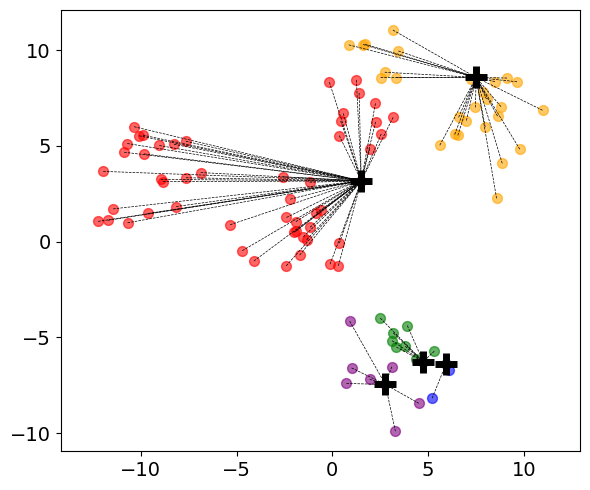

In [9]:
plot_data(X, labels=labels, centroids=centroids)

In this plot, the colors mark the cluster, i.e., all data points in the same color are assigned to the same cluster. The thin dashed lines between data points and centroids reflect the distance between each data point to its nearest cluster. For example, all orange data points are closest to the top right-most centroid.

That's all there is to the assignment step &mdash; again, ignoring the non-trivial task of efficiently computing all distances!

### Update Step

When looking at the previous plot showing the first allocation of data points to clusters, it is quite clear that the current centroids are not the means of their data points. Particularly for the red cluster it is obvious that the means is likely to be much further to the left. However, recall that we have shown at the beginning that, for a given set of clusters, the SSE is minimized if the centroids are the means of their data points.

This is where the update step comes in: it "moves" each centroid to its cluster mean by computing the means of the cluster and assigning this mean as the new value of the centroid. The method `update_centroids()` implements this by iterating through all cluster ID $0$ to $K-1$, find all corresponding data points, and compute their mean. The only additional step we are doing here is to check if the mean for at least one of the clusters has indeed changed. Because, if no mean will change during the update step, this means that LLoyd's algorithm has converged and we are done. After all, once the means stop changing, the assignments of data points to clusters will stop changing too.

In [10]:
def update_centroids(X, centroids, labels):
    update_required = False

    for cluster_id in range(len(centroids)):
        # Get the indices of the data points belonging to current cluster
        indices = np.where(labels == cluster_id)[0]
        
        # Ignore empty clusters!
        if len(indices) == 0:
            continue

        # Compute new centroid as the mean of all data points in cluster
        cluster_mean = np.mean(X[indices], axis=0)

        # Set the centroid of the cluster to the mean
        if (centroids[cluster_id] == cluster_mean).all():
            continue
        else:
            centroids[cluster_id] = cluster_mean
            update_required = True
            
    return centroids, update_required

Also, notice that the method checks if there are any data points assigned to a cluster in the first place. As we will later see, K-Means may return empty clusters. Even with much better initialization methods such as K-Means++, the chance of getting an empty cluster is never $0\%$.

To continue our example, the code cell below uses method `update_centroids()` to compute the new means for our current set of clusters captured by `labels`; we only print the information if the mean of at least one cluster has changed as showing the location of the new centroids is much easier using a plot.

In [11]:
centroids, update_required = update_centroids(X, centroids, labels)

print(f"Did at least 1 cntroid change its location? {update_required}!")

Did at least 1 cntroid change its location? True!


**Side note:** If you run the previous code cell twice in a row, the output will naturally change from `True` to `False` since means will be the same for the same cluster assignment.

Like before, we can visualize the clusters and their centroid location using the `plot_data()` method.

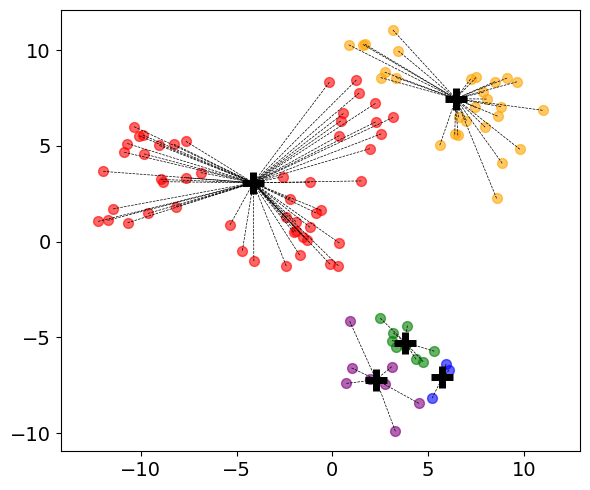

In [12]:
plot_data(X, labels=labels, centroids=centroids)

Every time the centroids move, their distance to all data points will change. This means that the closest centroids of a data point might change after the update step. In other words, we have to go back to the assignment step to check again which centroid is the closed for each data point. Any change in the cluster assignment will then, in turn, require updating the location of the centroids again. This iteration between assignment and update step will continue until no further changes are happening; we capture this in the update step.

### Complete Algorithm

With the assignment and update step covered and implemented, we have all the parts needed to implement Lloyd's algorithm to perform K-Means clustering. After all, we essentially only need to wrap the assignment and update steps into a loop  and iterate through both steps until the centroids stop changing. However, before we do this, let's actually implement the SSE as a Python method. While this method is actually not needed for the algorithm itself, it will help us to assess the quality of the resulting clusterings. Recall the the SSE is defined as:

$$\large
\text{SSE} = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \lVert\mathbf{x}_i - \boldsymbol{\mu}_k\rVert^2
$$

The method `compute_sse()` provides a straightforward implementation of this expression; notice the two nested `for` loops representing the two sums. Again, the focus here is on clarity and not on an implementation optimized for efficiency (e.g., by computing all distances for a cluster in one go using vectorized computations).

In [13]:
def compute_sse(X, labels, centroids):
    sse = 0.0

    for cluster_id in range(len(centroids)):
        # Get the indices of the data points belonging to current cluster
        indices = np.where(labels == cluster_id)[0]
        # Get centroid of current cluster
        cluster_centroid = centroids[cluster_id]
        # For each point in cluster compute distance to its centroid and sum up all distances.
        for sample in X[indices]:
            sse += np.square(np.linalg.norm(sample - cluster_centroid))
    
    return np.round(sse, decimals=2)

Finally, the method `kmeans()` in the code cell below implements Lloyd's algorithm. The method essentially just combines the steps we have covered: initializing the centroids, and then iterating through the assignment and update step until we are done (i.e., the centroids no longer change). You may notice that we used the function to initialize the centroids as an input argument. We do this, so we can later replace our basic initialization method with a more sophisticated one, without changing the `kmeans()` method. We also compute and return the SSE of the final clustering within the method, which is merely for convenience when inspecting the results.

In [14]:
def kmeans(X, init_centroids_func, k=2, centroids=None, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    # Initialize centroids
    centroids = init_centroids_func(X, k=k, centroids=centroids)
    
    while True:
        ### Assigment Step ###
        labels = assign_clusters(X, centroids)

        ### Update Step ###
        centroids, update_required = update_centroids(X, centroids, labels)

        # Check of last update resulted in any change; if not, stop
        if update_required == False:
            break

    # Compute SSE (not required for the algorithm, just for convenience here)
    sse = compute_sse(X, labels, centroids)

    return np.asarray(labels), np.asarray(centroids), sse

Let's use the method `kmeans()` to run Lloyd's algorithm on our example dataset. By default, we set $K=5$ to find five clusters. To visualize the resulting set of clusters, we again use the method `plot_data()` to plot the clusters together with their centroid. When provided with the SEE, the method will also show the value as part of the plot.

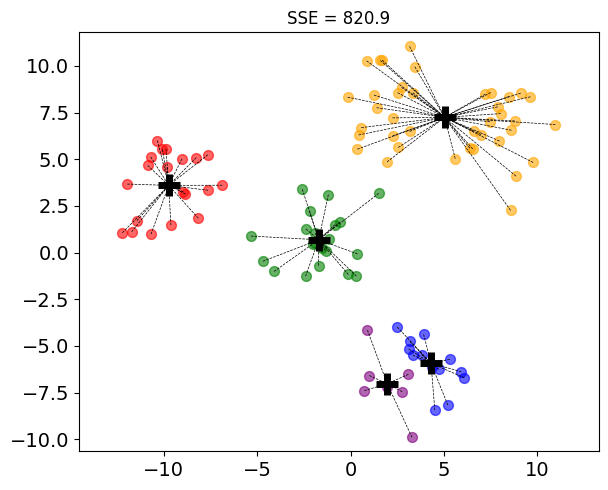

In [15]:
labels, centroids, sse = kmeans(X, init_centroids_basic, k=5, random_state=0)

plot_data(X, labels=labels, centroids=centroids, sse=sse)

While method `kmeans()` implements Lloyd's algorithm just fine, it "only" returns the final clustering and centroids. This is, of course, perfectly fine for any practical applications. However, to better appreciate how the algorithm works and behaves, it would be nice to see how the set of clusters change after each assignment and update step. The code cell below, therefore, implements the method `kmeans_history()` which extends method `kmeans()` by keeping track of all current clusters and centroids after each assignment and update step; the algorithm itself does not change at all.

In [16]:
def kmeans_history(X, init_centroids_func, k=2, centroids=None, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    # Initialize centroids
    centroids = init_centroids_func(X, k=k, centroids=centroids)
    
    label_history = []      # Only needed to record all changes for creating the animation
    centroid_history = []   # In practice, we generally do no care about the intermediate steps
    sse_history = []
    
    while True:
        ### Assigment Step ###
        labels = assign_clusters(X, centroids)

        # Record labels, centroids, and sse after assignment step
        label_history.append(labels.copy())
        centroid_history.append(centroids.copy())
        sse_history.append(compute_sse(X, label_history[-1], centroid_history[-1]))

        ### Update Step ###
        centroids, update_required = update_centroids(X, centroids, labels)

        # Check of last update resulted in any change; if not, stop
        if update_required == False:
            break

        # Record labels, centroids, and sse after update step
        label_history.append(labels.copy())
        centroid_history.append(centroids.copy())
        sse_history.append(compute_sse(X, label_history[-1], centroid_history[-1]))

    return np.asarray(label_history), np.asarray(centroid_history), np.asarray(sse_history)

Naturally, method `kmeans_history()` no longer just returns a list of labels and centroids, as well as an SSE values; it returns a list of lists of labels and centroids, as well as a list of SSE values. If we pass these outputs to the `plot_data()` method, the result will be an animated plot showing the progress of Lloyd's algorithm; just run the code cell below (which might take a few seconds to generate the animation).

In [17]:
label_history, centroid_history, sse_history = kmeans_history(X, init_centroids_basic, k=5, random_state=0)

plot_data(X, labels=label_history, centroids=centroid_history, sse=sse_history)

This animation shows two main things. Firstly, it shows the effect of the assignment step (the changing of the color of data points) and the update step (the change in location of the centroids). Just by looking at the movement of the centroids, you will notice that the changes are largest in the first iteration and become smaller and smaller as the algorithm progresses. This is arguably not surprising.

And secondly, if you look at the SSE values on top of the plot, you will notice that the value goes down after each assignment and update step. Again, this is expected since:

* The assignment step finds the shortest distances between data points and centroids
* The update steps moves the centroids to their respective cluster means

Both of these steps lower the SSE. To visualize the trend of SSE values across iterations, we provide the auxiliary method `plot_sse_history()` which plots the history of SSE values after each assignment and update step (marked in the plot by $A$ and $B$, respectively).

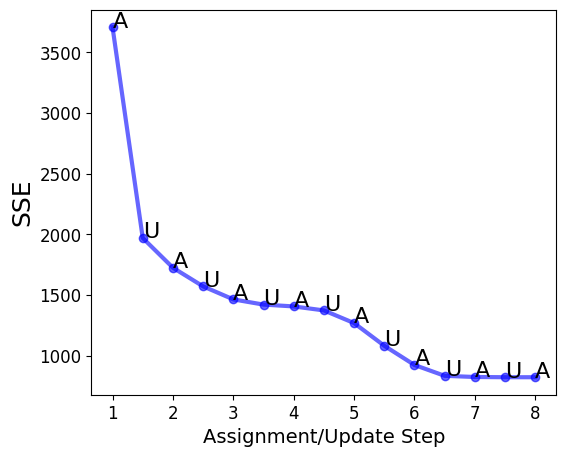

In [18]:
plot_sse_history(sse_history)

Again, the two main observations are that the SEE will always go down (until convergence) and that the changes to SEE tend to be largest early on and then become smaller and smaller. Of course, this overall trend depends on the initialization of the centroids. For example, if the initial centroids happen to be placed near their final locations, even the first changes to the SSE will be rather small.

We now have implemented Lloyd's algorithm to perform K-Means clustering. If you check the required code, you should appreciate that the implementation of the algorithm is quite straightforward. Of course, we made use of convenient NumPy methods and did not care about efficiency which simplified the code quite a bit. Still, Lloyd's algorithm makes K-Means one of the easiest clustering algorithms to implement. And when done with more emphasis on optimization and efficiency, it also handles large datasets quite well.

### K-Means++ Initialization

As we just saw, Lloyd's algorithm always converges. However, the algorithm converges to a **local optimum** and not necessarily to the global optimum that minimizes the SSE. Since the assignment and update step are essentially deterministic &mdash; apart from maybe corner cases of duplicate data points which we ignore here &mdash; the solution of the algorithm depends heavily on the initial centroid positions. If centroids are chosen by randomly selecting data points, as we have done so far, the following may happen:

* Multiple centroids may be initialized close together or even within the same true cluster; see above.
* Some "true" clusters may have no nearby initial centroid, causing them to be poorly represented.
* The algorithm may converge to a partition with a SSE than the global optimum.

In fact, the solutions we have seen so far with a final SSE of $820.9$ is not the best solution with the lowest SSE!

When initializing centroids for K-Means, we generally want them to be well spread out across the dataset rather than clustered together. If several centroids start in the same region, they may all compete to represent the same group of points, while other regions of the data remain unrepresented. This can cause the algorithm to converge to a poor local optimum, resulting in higher clustering error and less meaningful clusters. By choosing initial centroids that are far apart, each centroid is more likely to capture a different underlying cluster, leading to faster convergence and better clustering quality.

This is where **K-Means++ initialization** comes in. It improves centroid initialization by selecting initial centroids that are well separated. First, one data point is chosen uniformly at random as the first centroid. Then, each remaining point is assigned a probability proportional to the squared distance to its nearest already chosen centroid. A new centroid is sampled according to these probabilities, making points that are far from existing centroids more likely to be selected. In other words, the far away a data point is from all currently existing centroids, the more likely this data point is chosen as the next centroid. This process is repeated until $K$ centroids have been chosen. The method `init_centroids_kmeanspp()` in the code cell below implements this idea.

In [19]:
def init_centroids_kmeanspp(X, k=2, centroids=None):
    if centroids is not None:
        return np.asarray(centroids)
    else:
        # Pick the first centroid randomly
        c1 = np.random.choice(X.shape[0], 1)
            
        centroids = X[c1]
           
        # Calculate and add c2, c3, ..., ck 
        while len(centroids) < k:
            
            # Calculcate squared(!) Euclidean Distances between data points and all centroids
            distances = euclidean_distances(X, centroids, squared=True)
            
            # Calculate the distances between the data points to the nearest centroid
            distances = np.min(distances, axis=1)

            # Sample randomly but proportional to the squared(!) distances
            idx = np.random.choice(np.arange(distances.size), 1, p=distances/distances.sum())[0]
                
            # Add next centroid c to the array of already existing centroids
            centroids = np.concatenate((centroids, [X[idx]]), axis=0)
        
        return np.array(centroids)

So see the method in action, let's apply to our example data to initialize $5$ centroids once more and the plot the result. Since K-Means++ initialization is non-deterministic, you should run the code cell multiple times to see different results.

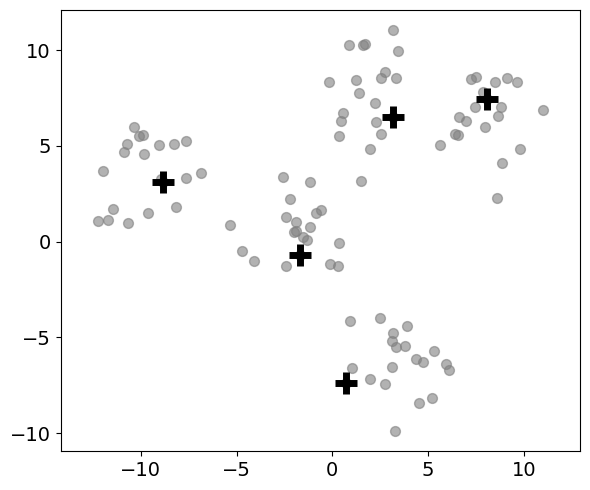

In [20]:
centroids = init_centroids_kmeanspp(X, k=5)

plot_data(X, centroids=centroids)

Overall, you should observe that the centroids are much more likely to be spread out and much less likely to be bunched together &mdash; although, this might still occasionally happen due to the random nature.

**Side note:** When looking at the algorithm and the goal of spreading out the centroids, it might seem a tempting idea to always pick the data point farthest away from all current centroids as the next centroid. However, this can actually lead to poor choices because it makes the initialization overly sensitive to outliers and noise. An isolated point far away from the main data distribution is basically guaranteed to be selected as a centroid even though it does not represent a meaningful cluster. For example, if there are two large clusters and one isolated outlier, the farthest-point strategy may waste a centroid on the outlier.

The random sampling of K-Means++ does give higher probability to far-away points, encouraging centroids to spread out, but it does not force the algorithm to choose the absolute farthest point. As a result, K-Means++ balances two goals:

* **Diversity:** New centroids are likely to be far from existing ones.
* **Robustness:** Outliers are not guaranteed to be selected, and dense regions containing many distant points collectively have a high chance of contributing a centroid.

In general, K-Means++ initialization is more likely to place centroids in the large clusters because many points in those clusters contribute to the sampling probability, making the initialization more representative of the overall data structure.

Lastly, the probabilistic sampling rule in K-Means++ is not just a heuristic for spreading out centroids. It was specifically designed to provide theoretical guarantees on the quality of the initialization. By selecting new centroids with probability proportional to the squared distance from the nearest existing centroid, K-Means++ is guaranteed in expectation to produce an initial clustering whose objective value is within a factor of $O(\log K)$ of the optimal K-Means solution. This is a significant improvement over purely random initialization, which can lead to arbitrarily poor solutions. Thus, the squared-distance sampling strikes a balance between encouraging diverse centroid placement and ensuring provably good clustering quality. However, a deeper analysis of these theoretical guarantees are beyond this scope of this introductory notebook.

With the method `init_centroids_kmeanspp()` we can now run K-Means again on our example dataset; we only need to pass `init_centroids_kmeanspp` as an argument to method `kmeans()`.

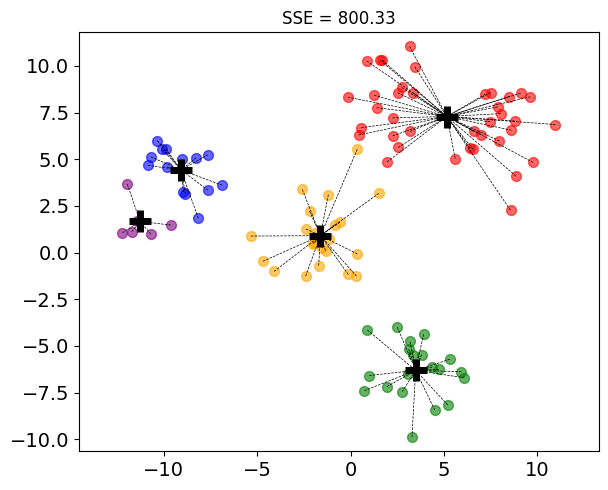

In [21]:
labels, centroids, sse = kmeans(X, init_centroids_kmeanspp, k=5, random_state=0)

plot_data(X, labels=labels, centroids=centroids, sse=sse)

With the default values, mainly `random_state=0`, you should see that the SSE dropped from $820.9$ down to $800.33$. However, this is still far from the best solution we can find; as we will see later. The important take-away message is that K-Means++ still does not guarantee the best solution, it "only" makes it more likely to start with an initialization of centroids that will converge to the best solution. After all, the K-Means++ initialization is still random.

### Finding the best Choice for $K$

In all examples so far, we set $K=5$ by default. And we kind of knew that this is a meaningful value because we explicitly generate the example data having $5$ centers. In practice, of course, we would not have this information when working with real-world data. Even more, most data is likely to have much more than just $2$ features, meaning that we cannot simply plot the data to potentially eye-ball a good value for $K$. And since we typically work with unlabeled data, we do not have any ground truth to compare a resulting clustering with.

One of the most basic ways to get a sense of the quality of a clustering is to perform K-Means for various values of $K$ and compare the result in terms of the final SSE values. To give an example, the code cell below performs K-Means for values of $K$ ranging from $2$ to $20$. For each choice of $K$ we run LLoyd's algorithm using K-Means++ initialization, and then report the mean SSE and standard deviation for each $K$ value.

In [22]:
def evaluate_k(X, max_k=20):
    sse_data = []
    
    for k in tqdm(range(2, max_k+1)):
        sse_k = []
        # Perform K-Means 50 times with different random initializations
        for i in range(20):
            _, _, sse = kmeans(X, init_centroids_kmeanspp, k=k)
            sse_k.append(sse)
        # Add mean and standard deviation for current k to result            
        sse_data.append((k, np.mean(sse_k), np.std(sse_k)))
    
    return np.asarray(sse_data)

To visualize the data, we provide another auxiliary method `plot_elbow()` to plot the SSE (mean and standard deviation) for each choice of $K$; why we call this method like that, we will see in a moment.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:04<00:00,  4.19it/s]


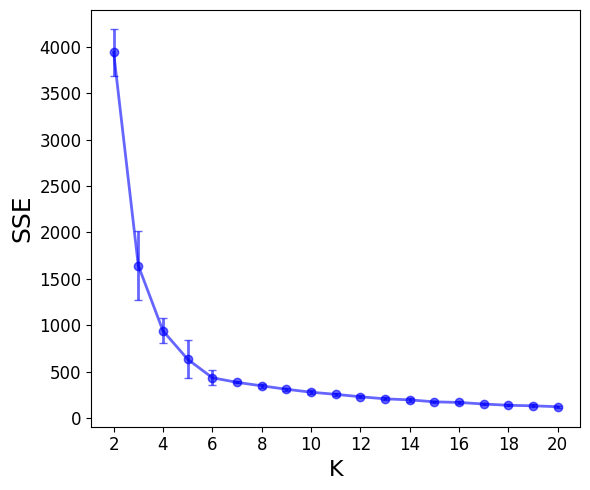

In [23]:
sse_data = evaluate_k(X)

plot_elbow(sse_data)

The most prominent observation is that the SSE will go down for increasing values of $K$. This is not surprising since the more clusters we have, the smaller these clusters will be. This, in turn, yields smaller and smaller SSE values. In other words, the SSE does not "penalize" large numbers of clusters, and we do not get some plot with a minimum or maximum value we can use to determine the best value for $K$.

However, this plot is still informative. For example, when we increase the number of clusters one by one from $2$ to $5$, we see some noticeable reductions in the SSE. When increasing $K$ from $5$ to $6$, on the other hand, the reduction in SSE is almost negligible. In terms of the plot we see that there is an "elbow" where the reduction of the SSE suddenly drops. This is why this plot is also called the **elbow curve**. And it is this elbow which suggests the best value of $K$, which in our example &mdash; again, unsurprisingly &mdash; is indeed at $K=5$. For our simple example dataset, the elbow is quite pronounced, making it straightforward to pinpoint the best choice of $K$. For other data, the elbow may be much less pronounced; as we will see later with some other examples.

In short, while the elbow curve provides a simple heuristic for selecting the number of clusters by examining the reduction in SSE, it is often subjective because the "elbow" may not be clearly defined. Consequently, more sophisticated cluster validation metrics have been developed to provide a more objective assessment of clustering quality. For example, the **Silhouette Score** evaluates both cluster cohesion and separation and naturally penalizes solutions with an excessive number of clusters that do not meaningfully improve structure. Other metrics, such as the **Calinski–Harabasz Index** and **Davies–Bouldin Index**, assess different aspects of cluster compactness and distinctiveness. These measures can offer a more robust basis for model selection, particularly when the elbow method yields ambiguous results. However, a comprehensive discussion of cluster validation metrics is beyond the scope of this notebook.

---

## Analysis & Behavior

In the previous section, we covered in great detail Lloyd's algorithm, the de-fact standard algorithm to implement K-Means &mdash; that is, the most popular way to minimize the SSE optimization objective. Besides describing and implementing a clustering algorithm such as K-Means, an important motivation is to investigate how the algorithm might behave in practice, particularly on different types of datasets. For example, we already mentioned that Lloyd's algorithm does not guarantee to find the optimal solution and might even return empty clusters.

Furthermore, evaluating its performance across datasets with varying cluster shapes, densities, sizes, and levels of noise provides valuable insights into its strengths and limitations.  Such experiments help identify the characteristics of data for which K-Means is well suited and highlight situations where alternative clustering algorithms may be more appropriate. This comparative understanding is essential for selecting suitable clustering techniques in practical applications.

In this section, we therefore explore the "nature" of K-Means (more specifically: Lloyd's algorithm) in more detail.

### Suboptimal Solutions

Let's first run a simple experiment where we perform K-Means clustering $100$ times on the same dataset with the same value for $K$ and the same initialization method K-Means++. The only difference is that we call the method `kmeans()` with a different random seed to cause a different random initialization of the centroids; recall that K-Means++ still performs some form of random sampling. Since `kmeans()` conveniently returns the SSE of the final clustering, we can keep track of the seed yielding the best and the worst SSE.

In [24]:
best_seed, best_sse   = None, sys.maxsize
worst_seed, worst_sse = None, -1

for seed in tqdm(range(100)):
    _, _, sse = kmeans(X, init_centroids_kmeanspp, k=5, random_state=seed)
    if sse < best_sse:
        best_seed, best_s = seed, sse
    if sse > worst_sse:
        worst_seed, worst_sse = seed, sse

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 143.97it/s]


Now that we know the values for the seed that give us the best and the worst SSE, we run `kmeans()` using these values to actually inspect the results. First, let's look at the best result, i.e., the clustering with the lowest final SSE.

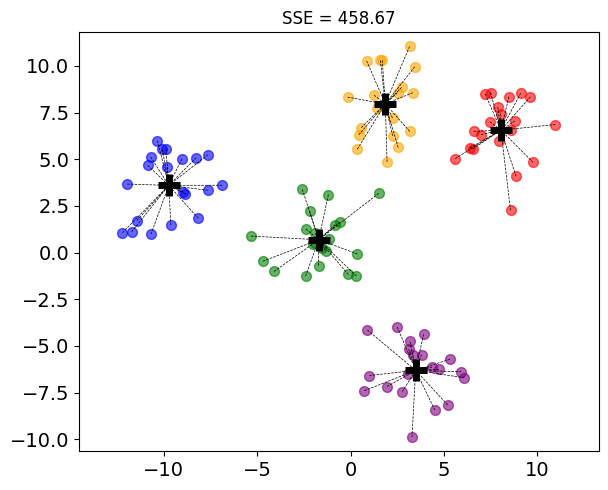

In [25]:
labels, centroids, sse = kmeans(X, init_centroids_basic, k=5, random_state=best_seed)

plot_data(X, labels=labels, centroids=centroids, sse=sse)

It is not surprising that this clustering yields the lowest SSE since this is the clustering we would see when just eye-balling this simple example dataset. In contrast, let's now checkout the resulting clustering for the seed returning the highest SSE among all $100$ runs.

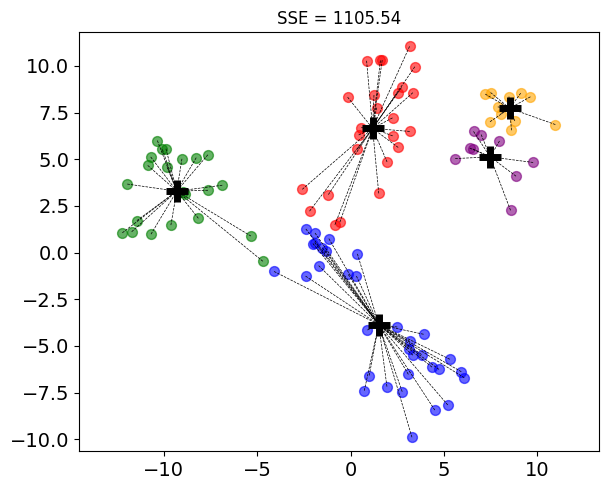

In [26]:
labels, centroids, sse = kmeans(X, init_centroids_kmeanspp, k=5, random_state=worst_seed)

plot_data(X, labels=labels, centroids=centroids, sse=sse)

This clustering looks clearly "not great", confirming that even K-Means++ initialization does indeed not guarantee the optimal solution. And keep in mind, in practice you typically have more than two or three features and therefore not allowing you to just plot the clustering.

Thus, in practice, several independent runs of K-Means are therefore performed, and the solution with the lowest clustering objective is selected. When combined with K-Means++ initialization, which provides a more informed choice of initial centroids, repeated runs have a high probability of finding a near-optimal or optimal solution &mdash; or at least we can avoid a very suboptimal solution with a very high probability. This strategy is particularly effective when the computational cost of multiple runs is acceptable, for example when the dataset size is moderate and repeated executions remain practical.

### Empty Clusters

In principle, K-Means may yield empty clusters. However, in practice, when using proper centroid initialization methods such as K-Means++, the chance of empty clusters is generally very low. In fact, for our example dataset, we can only enforce an empty cluster by manually selecting a bad initial place for the centroids. The code cell below first "manually" initializes $5$ centroids and passes them to the `kmeans_history()` method to later generate an animation showing all the intermediate clusters after each assignment and update step.

In [27]:
centroids = np.asarray([
    [-10.0, 5.0],
    [0.0, 0.0],
    [5.0, 8.0],
    [5.0, 3.0],
    [-8.0, -8.0],
])

label_history, centroid_history, sse_history = kmeans_history(X, init_centroids_basic, k=len(centroids), centroids=centroids)

plot_data(X, labels=label_history, centroids=centroid_history, sse=sse_history)

Notice how the initial centroids at $(-8, -8)$ is so unfortunately placed that no data point is closest to this centroid. As such, during the assignment step, no data point will be assigned to this centroid. In this basic example, this centroid remains "alone" throughout all iterations. However, since the other centroids that have data points assigned to are likely to move during the update step, the behavior can be less straightforward &mdash; more specifically:

* A centroid $\boldsymbol{\mu}_k$ might start as an empty cluster, but after some assignment and update steps, the other centroids might have moved such that some data points are now closest to $\boldsymbol{\mu}_k$ and therefore assigned to $\boldsymbol{\mu}_k$.

* A centroid $\boldsymbol{\mu}_k$ might start as a non-empty cluster, but after some assignment and update steps, the other centroids might have moved such that no data points are now closest to $\boldsymbol{\mu}_k$, making $\boldsymbol{\mu}_k$ and empty cluster.

The latter case means that, even when initially placing the centroids at locations of existing data points &mdash; meaning that all centroids will have at least one data point assigned to them &mdash; there is still the chance that a centroid might end up "alone" due to the moving of the centroids as part of the update step. That being said, this chance is exceedingly low in practice, just not $0\%$.

**Side note:** In principle, it is conceivable to "enforce" empty clusters by choosing a value for $K$ larger than the number of data points $n$. However, most practical implementations of K-Means will throw an error in this case since they no longer can place all centroids at unique locations of existing dataset. And in any case, looking for more clusters than data points has no meaningful practical application.

### Natural Clusters

K-means naturally favors **blob-like (globular) clusters** because it represents each cluster by its centroid (mean) and assigns points to the nearest centroid. Its objective is to minimize the SSE, which works best when clusters are compact, roughly spherical, and of similar size and density. Such cluster shapes are common in data generated by measurement noise or random variation around a central prototype, for example customer groups with similar purchasing behavior or sensor observations concentrated around typical operating conditions.

However, many real-world datasets contain **natural clusters** that are not blob-like. Examples include elongated, curved, ring-shaped, or density-based structures, such as road networks, biological populations, or trajectories in spatial data. In these cases, points may belong together because of connectivity or underlying geometry rather than proximity to a single center. Since K-means can only partition space into regions around centroids, it may split a natural cluster into multiple parts or merge distinct clusters, motivating the use of alternative clustering methods that can capture more complex shapes.

Of course, K-Means can still be applied to find cluster on these types of datasets. The question is how good the results might be. The better appreciate this, let's look at a few "artificial" datasets and see how K-Means behaves and whether or not it returns clusters that matches our expectations or preferences. We first consider a dataset with actually $3$ blob-like clusters but of different sizes.

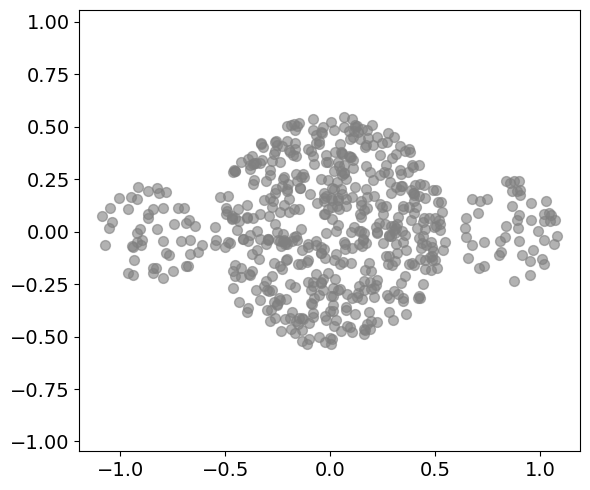

In [28]:
X_triple = pd.read_csv(demo_data_triple).to_numpy()

plot_data(X_triple)

If you would ask someone, how many clusters they say and what they should be, the answer would probably be the $3$ kind of obvious blobs. With this in mind, let's run Lloyd's algorithm on this dataset with $K=3$, and then plot the clusters.

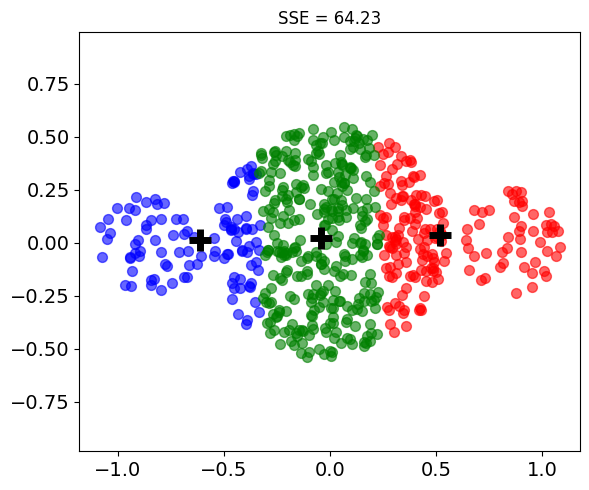

In [29]:
labels, centroids, sse = kmeans(X_triple, init_centroids_kmeanspp, k=3)

plot_data(X_triple, labels=labels, centroids=centroids, sse=sse, show_links=False)

Clearly, the results show that K-Means does not meet our expectations here. One could rightly justify this result by arguing that the blobs are very close together. Thus, let's look at another example where the blobs are much better separated. On the other hand, the blobs have not only a different size but also a different density.

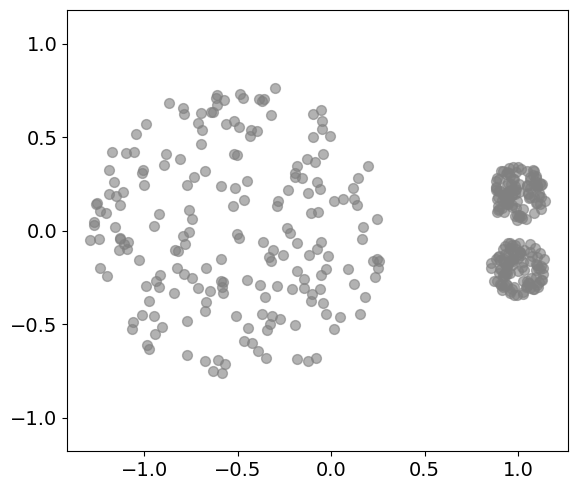

In [30]:
X_densities1 = pd.read_csv(demo_data_densities1).to_numpy()

plot_data(X_densities1)

Again, our intuition might tell us that there are $3$ clusters. But when applying K-Means with $K=3$m we get:

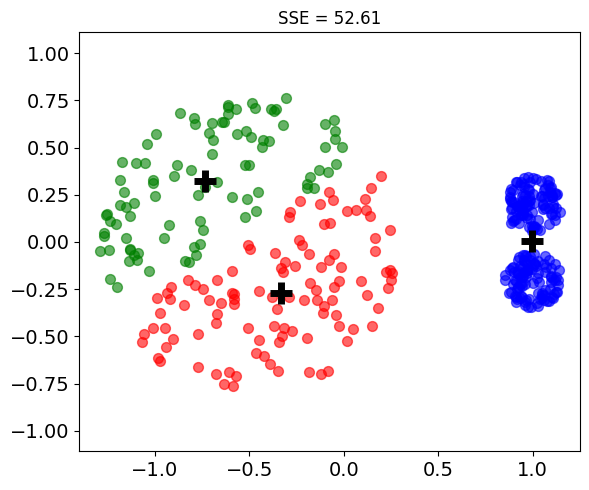

In [31]:
labels, centroids, sse = kmeans(X_densities1, init_centroids_kmeanspp, k=3)

plot_data(X_densities1, labels=labels, centroids=centroids, sse=sse, show_links=False)

Once you see the result and the final locations of the centroids, it is typically not difficult that this solution indeed minimizes the SSE. Another type of dataset K-Means does not really work well with is shown below. Here, we have some underlying random-looking distribution of data points both with $2$ much more dense regions.

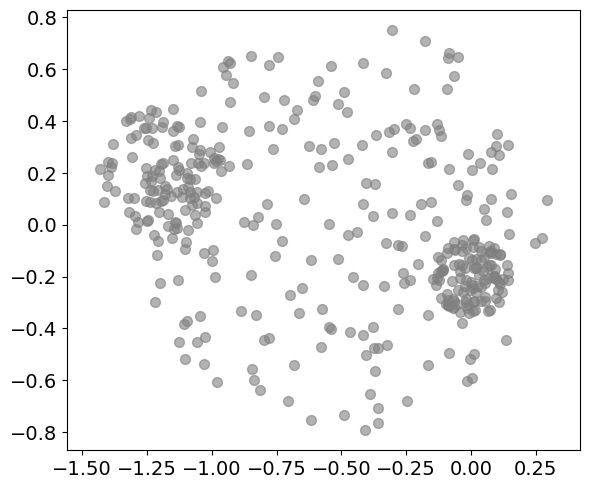

In [32]:
X_densities2 = pd.read_csv(demo_data_densities2).to_numpy()

plot_data(X_densities2)

Ideally, we would like to capture these $2$ dense regions and "ignore" the remaining datapoints. Cluster algorithms such as DBSCAN that explicitly take the density of data points into account are capable of accomplishing this. K-Means, considers (only) distances and not density. Thus, when applied on this dataset, we get the result as shown below. Keep in mind that we are even "cheating" here since we can easily plot this dataset therefore see the $2$ clusters we want, and therefore set $K=2$.

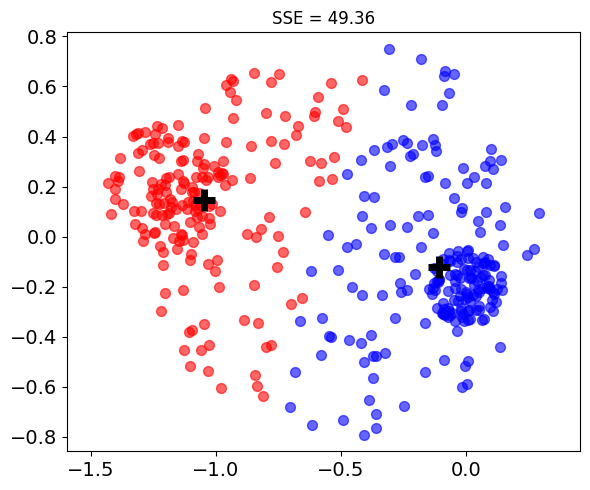

In [33]:
labels, centroids, sse = kmeans(X_densities2, init_centroids_kmeanspp, k=2)

plot_data(X_densities2, labels=labels, centroids=centroids, sse=sse, show_links=False)

The next dataset features a data distribution that has clearly clusters that are not blob-like at all. Moreover these two clusters also overlap &mdash; that is, they are not linearly separable (note that this is not an important characteristic here; it just emphasizes the fact that both clusters are very close together.

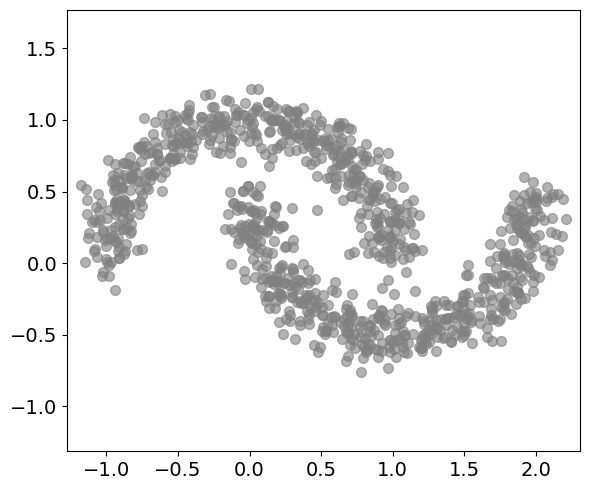

In [34]:
X_moons = pd.read_csv(demo_data_moons).to_numpy()

plot_data(X_moons)

Given that this data distribution features these two very obvious clusters, we would clearly prefer any cluster algorithms to indeed return them as the results. However, as the clusters are not blob-like and so close together, the result returned by K-Means with $K=2$ does once again not match our expectations; see below.

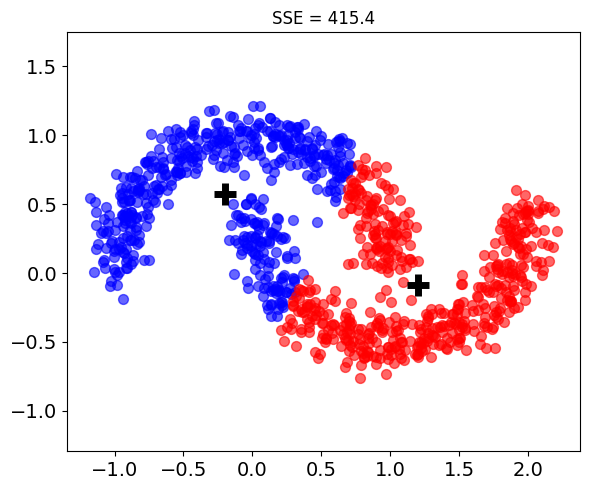

In [35]:
labels, centroids, sse = kmeans(X_moons, init_centroids_kmeanspp, k=2)

plot_data(X_moons, labels=labels, centroids=centroids, sse=sse, show_links=False)

Lloyd's algorithm with $K=2$ will split the $2$ natural clusters when minimizing the SSE. The only way to ensure that points from both natural clusters do not end up in the same K-Means cluster is to increase the value for $K$ more and more. For example, the plot below shows the set of clusters after running Lloyd's algorithm with $K=10$.

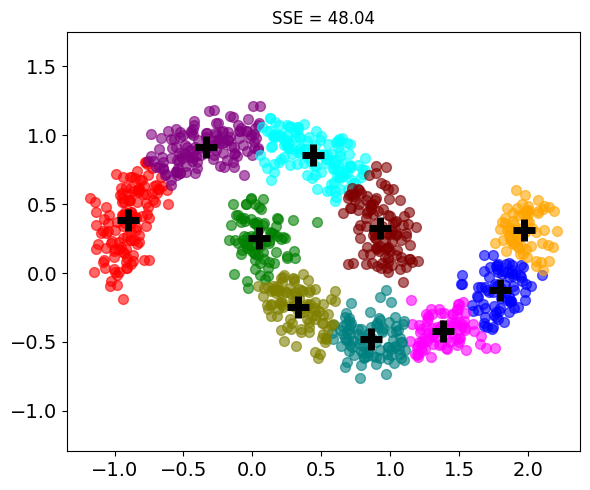

In [36]:
labels, centroids, sse = kmeans(X_moons, init_centroids_kmeanspp, k=10)

plot_data(X_moons, labels=labels, centroids=centroids, sse=sse, show_links=False)

On the flip side, of course, now multiple K-Means clusters form each of the $2$ natural clusters. An even worse case is the following dataset featuring $2$ concentric rings as the overall data distribution.

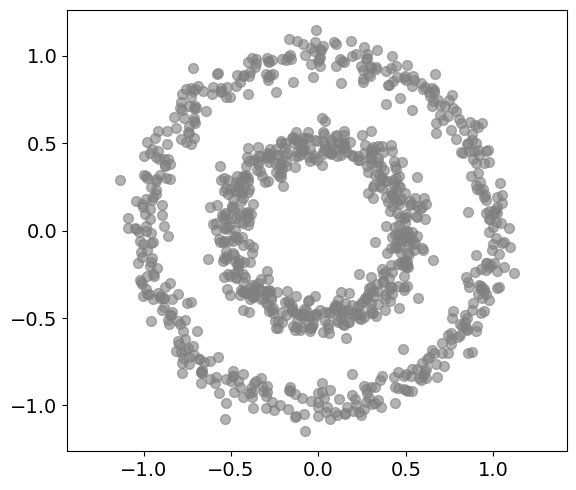

In [37]:
X_circles = pd.read_csv(demo_data_circles).to_numpy()

plot_data(X_circles)

While this data distribution might challenge the idea of what a cluster is, there are some cluster algorithms (e.g., DBSCAN or Hierarchical Clustering with Single Linkage) that manage to return these $2$ rings as cluster, K-Means with $K=2$ clearly fails, as shown by the output of the code cell below.

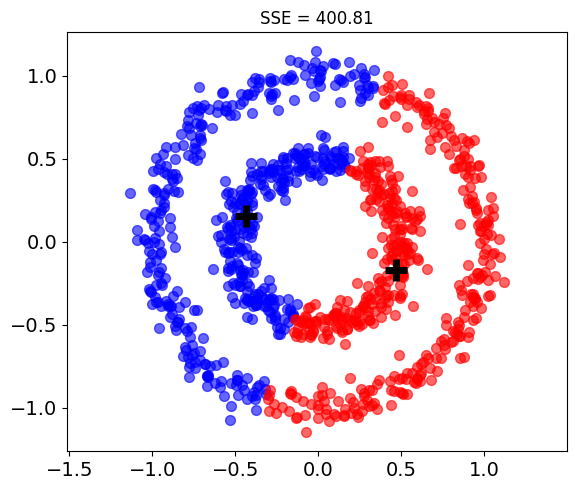

In [38]:
labels, centroids, sse = kmeans(X_circles, init_centroids_kmeanspp, k=2)

plot_data(X_circles, labels=labels, centroids=centroids, sse=sse, show_links=False)

In this case, even setting $K=10$ will not prevent that data points in the same K-means clusters come from different rings; see below. As a side note, we could increase $K$ even further to avoid that, but the `plot_data()` supports only $10$ different colors before reusing them in case of more then $10$ clusters.

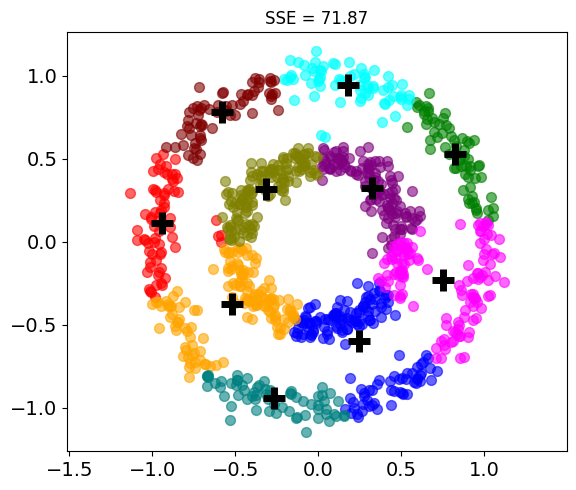

In [39]:
labels, centroids, sse = kmeans(X_circles, init_centroids_kmeanspp, k=10)

plot_data(X_circles, labels=labels, centroids=centroids, sse=sse, show_links=False)

Let's now consider a dataset with a uniformly random data distribution:

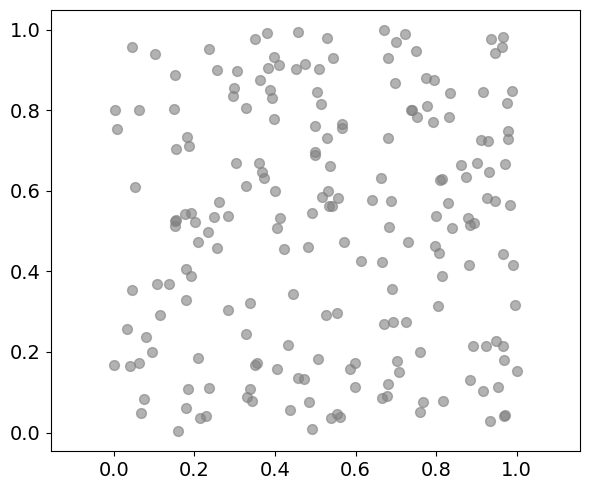

In [40]:
X_random = pd.read_csv(demo_data_random).to_numpy()

plot_data(X_random)

In the most intuitive sense, this dataset does not contain any cluster. However, K-Means is a complete clustering algorithm, meaning that every data point is assigned to a cluster. In other words, if we tell K-Means to find, say, $K=3$ clusters, the algorithm will return $3$ clusters even if they are not really there (in the classic interpretation of a cluster). Feel free to change the value of argument 'k' in the code cell below; Lloyd's algorithm will assign each data point to one of the $K$ clusters.

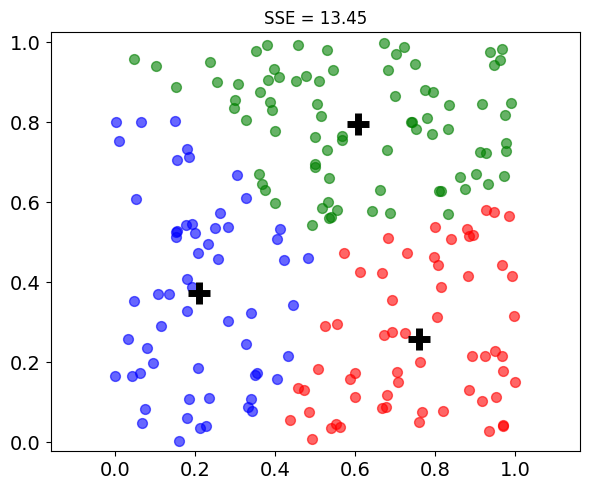

In [41]:
labels, centroids, sse = kmeans(X_random, init_centroids_kmeanspp, k=3)

plot_data(X_random, labels=labels, centroids=centroids, sse=sse, show_links=False)

Particularly for this random dataset, it is also worth having a look at the elbow curve to see how the SSE changes for different values of $K$.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:06<00:00,  2.96it/s]


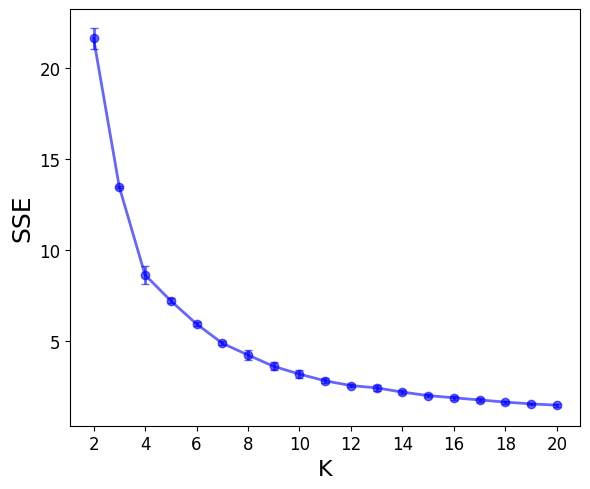

In [42]:
sse_data = evaluate_k(X_random)

plot_elbow(sse_data)

We already know that the SSE will always go down if we keep increasing $K$ and thus get smaller and smaller clusters. Still, the curve shows some kind of "elbow" around $5-7$ for $K$, even though it is much less pronounced. Of course, there is no obvious reason why, say, $K=6$ would be a good choice due to the uniformly random data distribution. This kind of shows that the elbow curve is far from a reliably metric and only makes sense if there is indeed a meaningfully pronounced elbow.

For the last example, let's go back to a dataset with well-separated blob-like clusters &mdash; i.e., the ideal case for K-Means. However, this dataset also has $3$ distinct outliers.

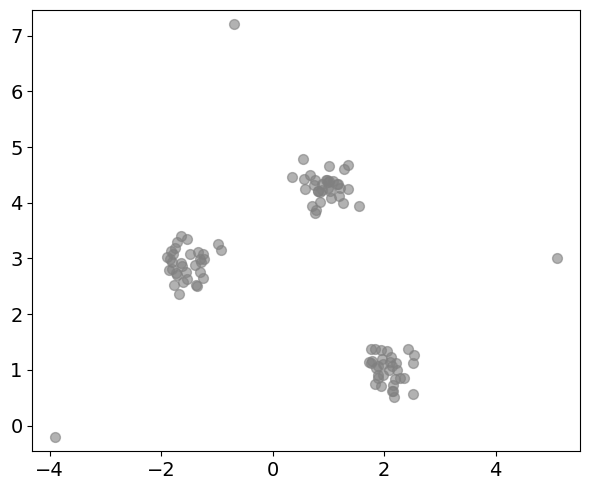

In [43]:
X_outliers = pd.read_csv(demo_data_outliers).to_numpy()

plot_data(X_outliers)

We already know that all outliers will be assigned to a cluster; K-Means yields complete clusterings. However, the outliers might cause one or more of the centroids to be placed at the location of an outlier. In this case, the $3$ blobs we can see will not form the core of the $3$ resulting clusters. In the code cell below, we explicitly set the `random_state` to ensure this "pathelogical" result. Try changing the random state value and run the code cell below; sometimes you will get a clustering that matches our expectations (the $3$ blobs each form their own cluster).

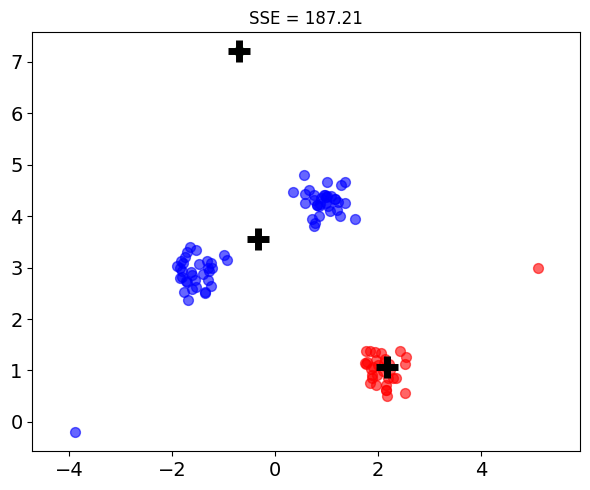

In [44]:
labels, centroids, sse = kmeans(X_outliers, init_centroids_kmeanspp, k=3, random_state=0)

plot_data(X_outliers, labels=labels, centroids=centroids, sse=sse, show_links=False)

To sum up, K-Means implicitly assumes that clusters are compact, roughly spherical ("blob-like"), and can be well represented by their centroids. The algorithm partitions data by assigning each observation to the nearest cluster center and minimizing the SSE. As a result, it performs well when the true data structure consists of well-separated, globular groups. However, when the data exhibits more complex or natural cluster structures (such as elongated, curved, nested, or density-based patterns) K-Means may produce unexpected or misleading results by splitting a natural cluster into multiple groups or merging distinct clusters into one.

This highlights an important principle in clustering: no single algorithm is universally appropriate for all datasets. The successful application of K-Means, or any clustering technique, requires a good understanding of the underlying data and the assumptions made by the algorithm. Before selecting a clustering method, it is therefore essential to explore the data, assess its distribution and structure, and evaluate whether the algorithm’s assumptions are consistent with the characteristics of the dataset. Choosing a clustering approach that matches the data is often more important than the clustering algorithm itself.

---

## Summary

This notebook introduced **K-Means**, one of the most widely used and influential clustering algorithms in machine learning and data mining. K-Means aims to partition data into a predefined number of clusters by minimizing the within-cluster sum of squared distances between data points and their assigned cluster centroids. Owing to its conceptual simplicity, computational efficiency, and scalability, K-Means remains a common baseline and practical tool for exploratory data analysis and unsupervised learning.

The notebook first presented the optimization objective underlying K-Means and discussed how this objective can be approximately optimized using **Lloyd’s algorithm**, an iterative procedure that alternates between assigning points to their nearest centroid and updating centroids based on the current cluster memberships. To improve convergence and reduce sensitivity to poor initializations, the notebook also introduced **K-Means++**, a probabilistic initialization strategy that selects initial centroids in a more informed manner than random sampling.

To provide a deeper understanding of the algorithm, the notebook included a complete implementation of K-Means from scratch. This implementation illustrated the key components of the algorithm, including centroid initialization, cluster assignment, centroid updates, convergence detection, and objective function evaluation. Building the algorithm step by step helped connect the mathematical formulation with its practical implementation.

Finally, the notebook examined important characteristics and limitations of K-Means. In particular, it demonstrated that Lloyd’s algorithm is a heuristic optimization procedure that may converge to **locally optimal solutions**, making the final result dependent on the initialization. The notebook also discussed practical issues such as the occurrence of **empty clusters** during optimization and explored the behavior of K-Means on datasets containing **natural, non-globular cluster structures**. These experiments highlighted that K-Means implicitly assumes compact, blob-like clusters and may produce unintuitive results when this assumption is violated, emphasizing the importance of understanding both the data and the assumptions of the chosen clustering algorithm.